# Sesión 1 · Laboratorio
## Descomposición de series meteorológicas reales

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

---

### Datos

Trabajaremos con un *snapshot* de la base de datos del **ClimaLab** del IER, registrada en Temixco, Morelos:

- **Período:** 31 mayo 2023 – 20 junio 2025 (~2 años)
- **Resolución temporal:** 1 minuto
- **Volumen:** ~1.07 millones de observaciones
- **Variables (11):**

| Sigla | Variable | Unidad |
|-------|----------|--------|
| `tdb` | Temperatura de bulbo seco | °C |
| `rh` | Humedad relativa | % |
| `p_atm` | Presión atmosférica | hPa |
| `ghi` | Irradiancia global horizontal | W/m² |
| `dni` | Irradiancia directa normal | W/m² |
| `dhi` | Irradiancia difusa horizontal | W/m² |
| `uv` | Índice UV | — |
| `solar_altitude` | Altura solar | ° |
| `ws` | Velocidad del viento | m/s |
| `wd` | Dirección del viento | ° |
| `rain_acc` | Lluvia acumulada | mm |

### Objetivos del laboratorio

1. Cargar y explorar una serie meteorológica multivariada de tamaño realista.
2. Resamplear en distintas escalas temporales y entender qué se gana/pierde.
3. Identificar visualmente los componentes de tendencia y estacionalidad.
4. Aplicar `seasonal_decompose` y `STL` a series reales.
5. Decidir entre aditivo y multiplicativo con base en evidencia.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose, STL

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Carga e inspección inicial

El formato **Parquet** es columnar y comprimido: ocupa una fracción de lo que ocuparía un CSV equivalente y se lee mucho más rápido. Para series temporales grandes es la opción por defecto.

In [2]:
f = "../data/ClimaLab_2023-05-31_2025-06-20.parquet"

df = pd.read_parquet(f)
df.head()

variable,dhi,dni,ghi,p_atm,rain_acc,rh,solar_altitude,tdb,uv,wd,ws
date,,,,,,,,,,,
2023-05-31 18:59:00,7.391,21.710,9.66,641.4001,0.0,60.18,1.867189,27.78,0.0,336.6,0.0
2023-05-31 19:00:00,7.020,0.000,9.26,641.4001,0.0,60.46,1.663787,27.73,0.0,344.7,0.0
2023-05-31 19:01:00,6.603,2.945,8.83,641.3997,0.0,60.42,1.461872,27.71,0.0,319.1,0.0
2023-05-31 19:02:00,6.262,3.643,8.46,641.4001,0.0,60.81,1.261586,27.69,0.0,322.8,0.0
2023-05-31 19:03:00,5.952,7.574,8.02,641.3999,0.0,60.45,1.063073,27.65,0.0,346.9,0.0


In [3]:
print(f"Forma del DataFrame: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Período: {df.index.min()} a {df.index.max()}")
print(f"Duración: {df.index.max() - df.index.min()}")
print(f"Tipo de índice: {type(df.index).__name__}")
print(f"Zona horaria: {df.index.tz}")  # None → tiempo local "naive"

Forma del DataFrame: 1,076,768 filas × 11 columnas
Período: 2023-05-31 18:59:00 a 2025-06-20 00:00:00
Duración: 750 days 05:01:00
Tipo de índice: DatetimeIndex
Zona horaria: None


### 1.1 Discusión rápida sobre zonas horarias

El índice viene **sin zona horaria** (`tz=None`). En meteorología hay dos convenciones legítimas:

- **Hora local** (lo más cómodo para interpretar el ciclo diario, pero salta con el horario de verano si aplica).
- **UTC** (sin saltos, recomendado para almacenar y compartir datos).

Antes de resamplear o decomponer, **siempre** confirma con quien generó los datos. En ClimaLab los timestamps están en **hora local de Morelos (UTC−6, sin DST)**. Lo dejamos *naive* por simplicidad.

### 1.2 ¿Qué hay y qué falta?

In [4]:
# Conteo de NaN por columna
faltantes = df.isna().sum()
porcentajes = (faltantes / len(df) * 100).round(1)
pd.DataFrame({"NaN": faltantes, "%": porcentajes})

,NaN,%
variable,,
dhi,533536,49.5
dni,534987,49.7
ghi,533579,49.6
p_atm,0,0.0
rain_acc,0,0.0
rh,0,0.0
solar_altitude,0,0.0
tdb,0,0.0
uv,0,0.0


**Observación importante.** Los canales de radiación (`dhi`, `dni`, `ghi`) tienen ~50 % de valores `NaN`. ¿Por qué?

Porque los piranómetros típicamente reportan `NaN` (o son filtrados aguas arriba) cuando la altura solar es negativa, es decir, **de noche**. No es un *gap* de instrumento, es estructural. **Esto es un dato faltante de tipo MAR** (depende de otra variable observable: `solar_altitude`). Volveremos a esta distinción en el Bloque 5.

Para esta sesión nos enfocaremos primero en `tdb` (temperatura), que está completa.

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
dhi,543232.0,190.75,206.73,0.00,72.21,126.90,224.30,1360.00
dni,541781.0,462.64,331.38,0.00,75.29,545.30,758.40,1361.00
ghi,543189.0,509.65,336.64,0.00,192.20,513.20,809.00,1360.00
p_atm,1076768.0,875.89,90.17,443.27,861.50,865.23,876.43,1593.04
rain_acc,1076768.0,0.04,0.92,0.00,0.00,0.00,0.00,43.40
rh,1076768.0,57.10,24.15,-8.19,36.85,55.69,75.51,138.50
solar_altitude,1076768.0,0.52,45.10,-89.94,-38.85,0.79,39.76,89.93
tdb,1076768.0,24.45,4.94,10.98,20.51,24.16,27.90,39.93
uv,1076768.0,0.04,0.06,-0.35,0.00,0.00,0.06,0.31


### Pregunta de pizarrón

Mira los valores `max` de `p_atm` (1593 hPa) y `rh` (138.5 %). Físicamente, ¿son posibles?

> **Respuesta corta.** No. La presión atmosférica máxima registrada en la Tierra anda en ~1085 hPa, y la humedad relativa por definición no puede pasar de 100 % (con saturación). Estos son **outliers** que delatan un problema de calibración.

## 2. La serie a tres escalas

Con 1.07 M de puntos, graficar todo a resolución de 1 minuto es **inútil**: el pixelado mata la señal. La estrategia correcta es mirar la serie a múltiples escalas.

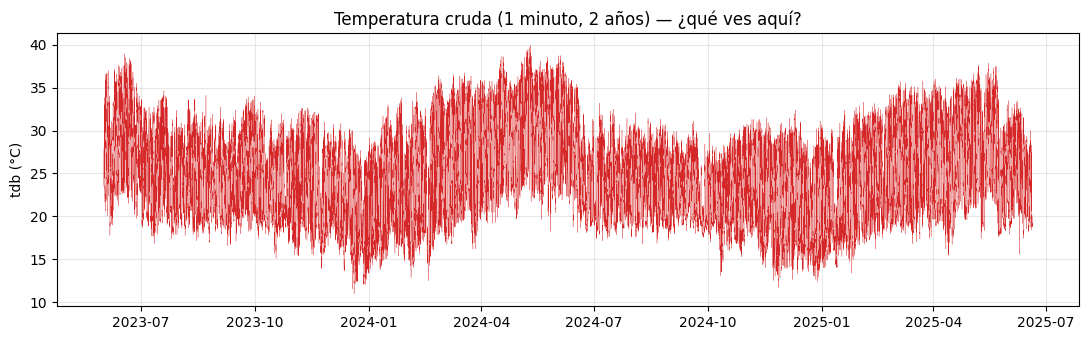

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df.index, df["tdb"], lw=0.2, color="C3")
ax.set_title("Temperatura cruda (1 minuto, 2 años) — ¿qué ves aquí?")
ax.set_ylabel("tdb (°C)")
plt.tight_layout()
plt.show()

In [7]:
# Resampling a tres escalas
horario = df.resample("1h").mean(numeric_only=True)
diario  = df.resample("1D").mean(numeric_only=True)

print(f"Original (1 min): {len(df):,} filas")
print(f"Horario  (1 h)  : {len(horario):,} filas")
print(f"Diario   (1 d)  : {len(diario):,} filas")

Original (1 min): 1,076,768 filas
Horario  (1 h)  : 18,007 filas
Diario   (1 d)  : 752 filas


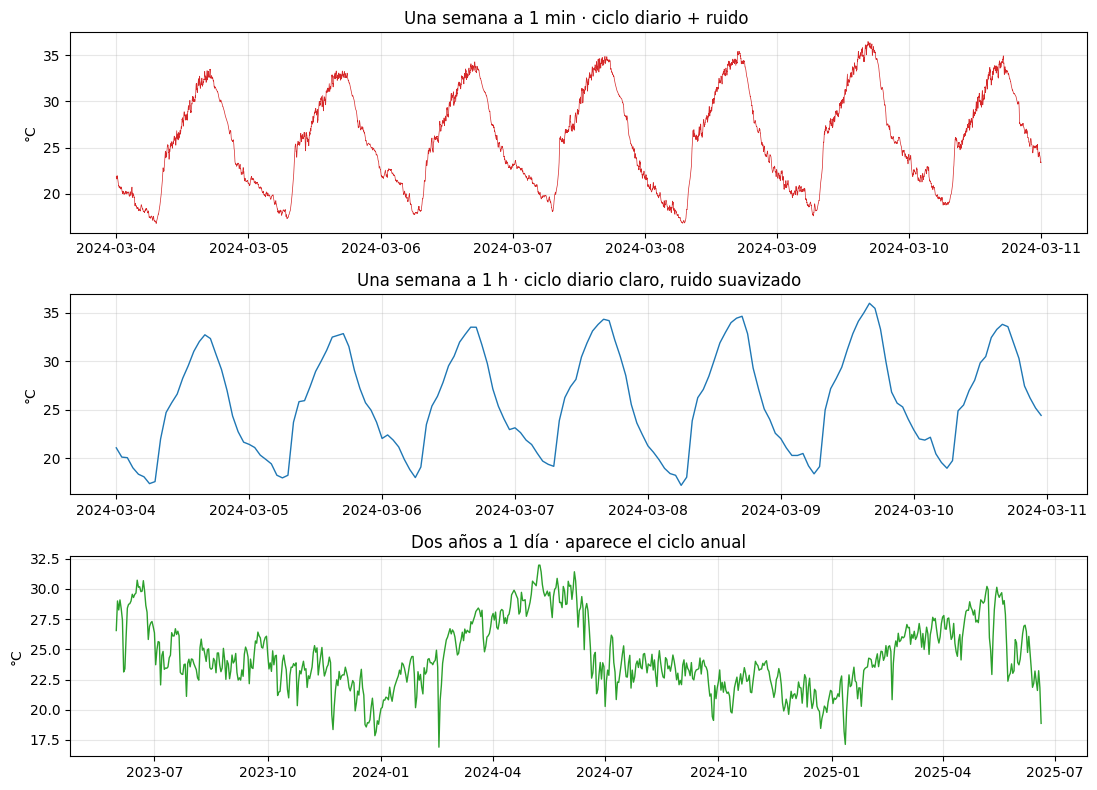

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)

# Una semana en 1 minuto: muestra el ciclo diario y la variabilidad turbulenta
semana = df.loc["2024-03-04":"2024-03-10", "tdb"]
axes[0].plot(semana.index, semana.values, lw=0.5, color="C3")
axes[0].set_title("Una semana a 1 min · ciclo diario + ruido ")
axes[0].set_ylabel("°C")

# Un mes a resolución horaria: muestra ciclo diario suavizado
mes = horario.loc["2024-03-04":"2024-03-10", "tdb"]
axes[1].plot(mes.index, mes.values, lw=1, color="C0")
axes[1].set_title("Una semana a 1 h · ciclo diario claro, ruido suavizado")
axes[1].set_ylabel("°C")

# Dos años a resolución diaria: muestra ciclo anual
axes[2].plot(diario.index, diario["tdb"], lw=1, color="C2")
axes[2].set_title("Dos años a 1 día · aparece el ciclo anual")
axes[2].set_ylabel("°C")

plt.tight_layout()
plt.show()

### Lo que enseña esta figura

| Escala | ¿Qué se vuelve visible? | ¿Qué se pierde? |
|--------|--------------------------|------------------|
| 1 min (semana) | Ciclo diario + ráfagas, microclima | El contexto anual |
| 1 h (mes) | Ciclo diario regular | Variabilidad sub-horaria |
| 1 d (2 años) | Ciclo anual | Todo lo intra-diario |

**No existe "la" escala correcta.** Existe la escala correcta *para la pregunta que estás haciendo*. Si te interesa la operación de un sistema de aire acondicionado, resoluciones horarias. Si te interesa la planeación energética anual, resoluciones diarias. Si te interesa la respuesta a una nube pasajera, datos minutales.

## 3. Identificación visual de componentes

Antes de meternos a la descomposición algorítmica, vale la pena entrenar el ojo. Tomemos la serie diaria de temperatura.

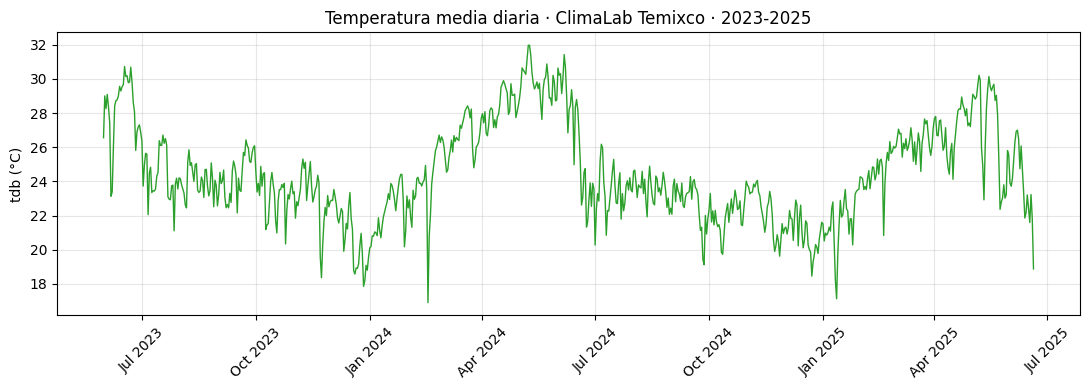

In [9]:
tdb_diario = diario["tdb"].dropna()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tdb_diario.index, tdb_diario.values, lw=1, color="C2")
ax.set_title("Temperatura media diaria · ClimaLab Temixco · 2023-2025")
ax.set_ylabel("tdb (°C)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ejercicio guiado (5 min, en parejas)


1. **Tendencia:** ¿hay una pendiente clara de fondo en estos 2 años?
2. **Estacionalidad anual:** ¿en qué meses están los máximos? ¿Y los mínimos? ¿Coincide con su intuición de Morelos?
3. **Variabilidad de alta frecuencia:** ¿cuán "ruidosa" es la serie día a día?
4. **Eventos atípicos:** ¿hay días que se salen claramente del patrón? ¿Cuándo?

> *Para Temixco, esperamos máximos en abril–mayo (antes de la temporada de lluvias) y mínimos en diciembre–enero. La amplitud anual típica es de ~7-10 °C en la temperatura media diaria.*

## 4. Descomposición clásica con `seasonal_decompose`

Apliquemos la herramienta básica: descomposición aditiva con período anual sobre la serie diaria.

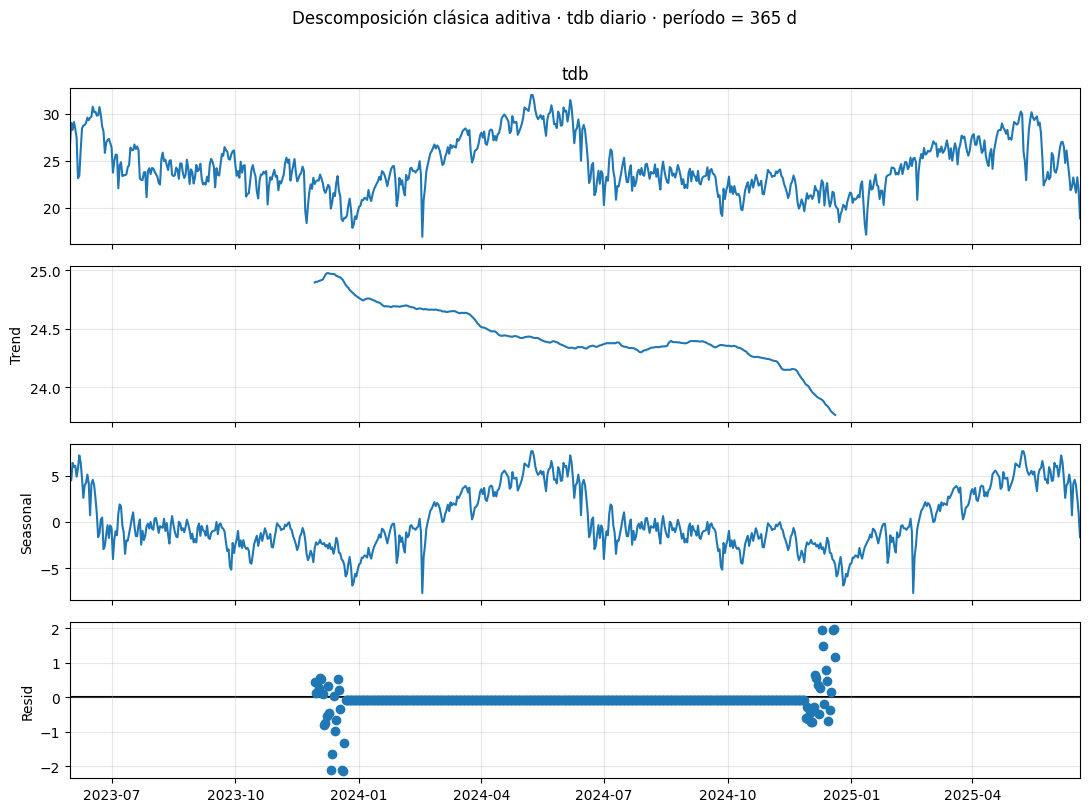

In [10]:
resultado_clasica = seasonal_decompose(
    tdb_diario,
    model="additive",
    period=365,
)

fig = resultado_clasica.plot()
fig.set_size_inches(11, 8)
plt.suptitle("Descomposición clásica aditiva · tdb diario · período = 365 d",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

### Lo que vemos

- **Trend.** Una curva suave que captura el cambio de baja frecuencia. Nota que **faltan datos en los extremos** (medio año al inicio y al final). Esa es una limitación de la media móvil centrada.
- **Seasonal.** El mismo patrón se repite *idéntico* año tras año. Esto es porque `seasonal_decompose` promedia todos los "1 de enero", todos los "2 de enero", etc.
- **Resid.** Lo que queda. *Aquí es donde viven las anomalías* y será materia del Bloque 4.

In [ ]:
# Verifiquemos cuántos NaN introdujo en los bordes
print("NaN en trend (clásica):", resultado_clasica.trend.isna().sum())
print("Total de puntos       :", len(tdb_diario))

## 5. Descomposición con STL

Ahora con STL en modo robusto.

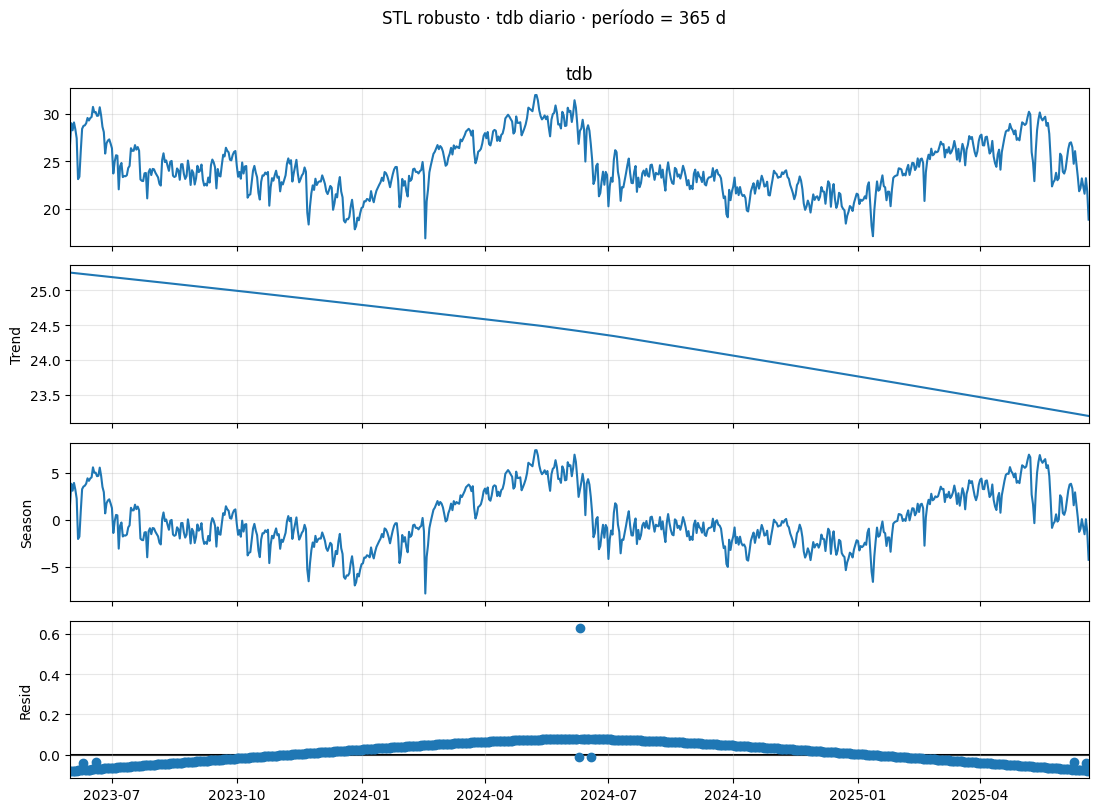

In [12]:
stl_anual = STL(tdb_diario, period=365, robust=True).fit()

fig = stl_anual.plot()
fig.set_size_inches(11, 8)
plt.suptitle("STL robusto · tdb diario · período = 365 d", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

### Diferencias respecto a la clásica

1. **Sin huecos en los bordes.** STL extrapola con LOESS en los extremos.
2. **Estacionalidad evolutiva.** Si comparas el patrón estacional del primer año con el del segundo, son *ligeramente* distintos. Eso es realista: 2024 no fue idéntico a 2023.
3. **Residuales más limpios** porque la robustez aplastó los outliers.

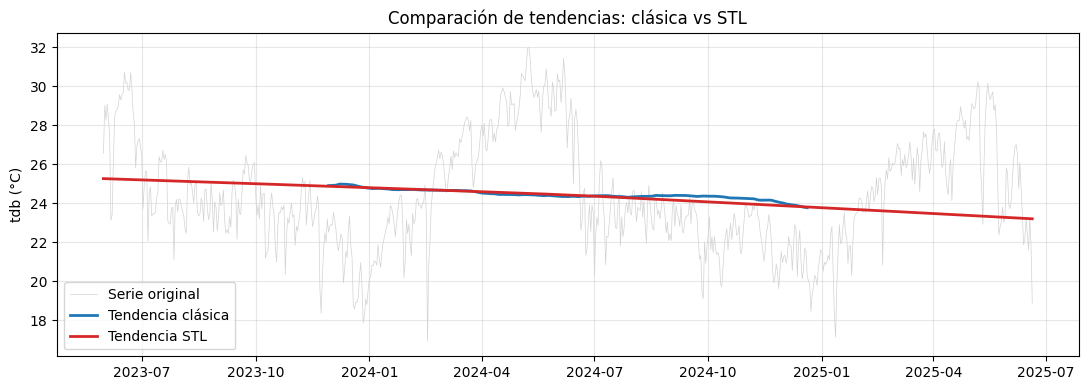

In [13]:
# Comparemos las componentes de tendencia
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tdb_diario.index, tdb_diario.values, lw=0.5, color="lightgray", label="Serie original")
ax.plot(resultado_clasica.trend.index, resultado_clasica.trend.values,
        lw=2, color="C0", label="Tendencia clásica")
ax.plot(stl_anual.trend.index, stl_anual.trend.values,
        lw=2, color="C3", label="Tendencia STL")
ax.legend()
ax.set_title("Comparación de tendencias: clásica vs STL")
ax.set_ylabel("tdb (°C)")
plt.tight_layout()
plt.show()

## 6. Ciclo diario vs ciclo anual: cuestión de escala

La temperatura tiene **dos** ciclos: el diario (24 h) y el anual (365 d). Para verlos por separado conviene trabajar en escalas distintas.

In [15]:
horario

variable,dhi,dni,ghi,p_atm,rain_acc,rh,solar_altitude,tdb,uv,wd,ws
date,,,,,,,,,,,
2023-05-31 18:00:00,7.391,21.710000,9.660000,641.400100,0.000000,60.180000,1.867189,27.780000,0.000000,336.600000,0.000000
2023-05-31 19:00:00,6.073,5.691222,8.083444,641.400063,0.000000,60.930000,-4.891853,27.291500,0.000000,321.168333,0.000000
2023-05-31 20:00:00,NaN,NaN,NaN,641.400020,0.000000,61.193729,-17.502141,26.672034,0.000000,255.032068,0.000000
2023-05-31 21:00:00,NaN,NaN,NaN,641.399875,0.000000,64.637966,-28.965914,25.673729,0.000000,306.613153,0.000000
2023-05-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-19 20:00:00,NaN,NaN,NaN,863.602195,0.015000,100.000000,-15.978739,18.899000,0.000067,278.707183,1.199983
2025-06-19 21:00:00,NaN,NaN,NaN,864.438203,0.006667,100.000000,-27.386284,19.044333,0.000150,275.521133,1.343117
2025-06-19 22:00:00,NaN,NaN,NaN,864.795360,0.003333,100.000000,-37.184314,19.069167,0.000183,135.902567,1.297650


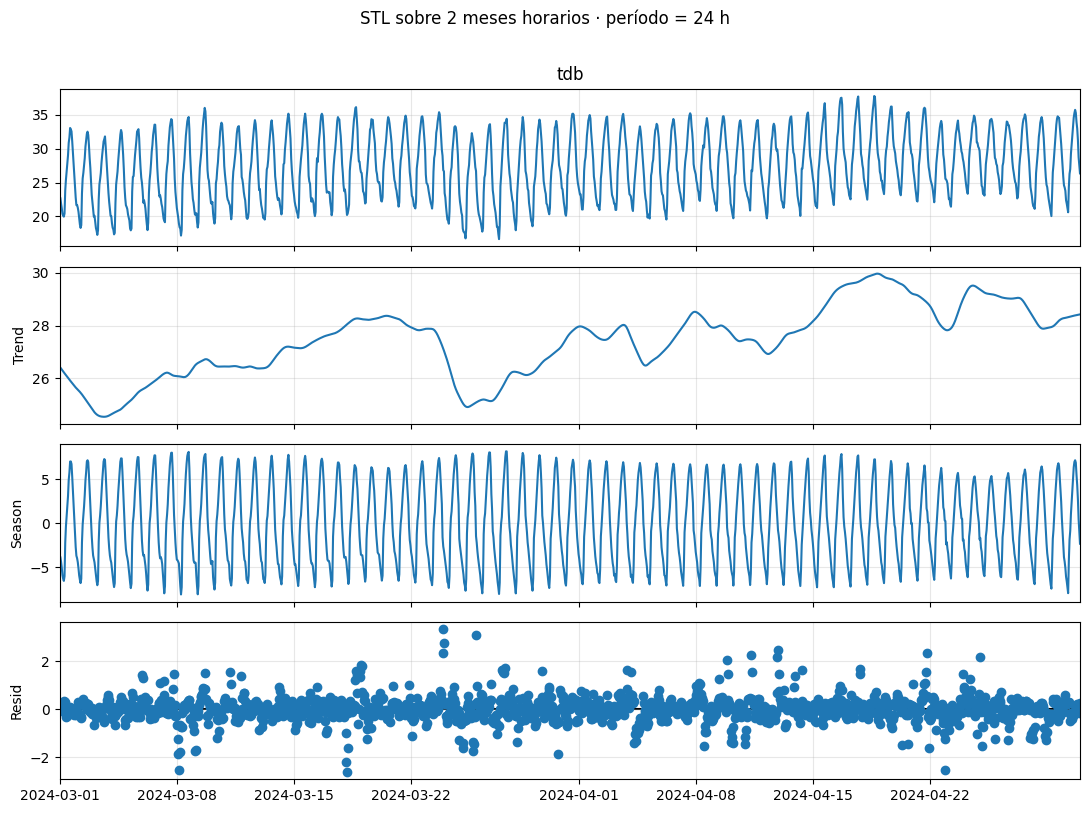

In [29]:
# Tomemos un mes a resolución horaria y descompongamos con período = 24
tdb_horario_mes = horario["tdb"].loc["2024-03":"2024-04"]
    
stl_diario = STL(tdb_horario_mes, period=24, robust=True).fit()

fig = stl_diario.plot()
fig.set_size_inches(11, 8)
plt.suptitle("STL sobre 2 meses horarios · período = 24 h",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

**Mensaje clave.** El parámetro `period` no es una propiedad de los datos, es **una elección consciente del analista** sobre qué ciclo quieres extraer. Si tienes datos horarios y le pones `period=24`, sacas el ciclo diario. Si tienes datos diarios y le pones `period=365`, sacas el ciclo anual.

Para tener *ambos* ciclos a la vez existe **MSTL** (Multiple STL), que veremos brevemente al final del Bloque 3.

## 7. ¿Aditivo o multiplicativo? Caso radiación

Veamos ahora una variable donde la elección importa: la **irradiancia global horizontal** (`ghi`) a escala diaria.

In [ ]:
# Promedio diario de ghi (W/m²): sólo durante el día son no-nulos
ghi_diario = diario["ghi"].dropna()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ghi_diario.index, ghi_diario.values, lw=1, color="C1")
ax.set_title("GHI promedio diario · ClimaLab Temixco")
ax.set_ylabel("GHI (W/m²)")
plt.tight_layout()
plt.show()

**Pregunta.** ¿Ves un *abanico*? ¿La amplitud estacional crece con el nivel?

Para esta variable la amplitud es relativamente estable porque el GHI promedio diario está acotado por la geometría solar (que es muy regular). Aún así, vamos a comparar las dos descomposiciones.

In [ ]:
ghi_diario.clip()

In [ ]:
# Aditivo
add = STL(ghi_diario, period=365, robust=True).fit()

# Multiplicativo: trabajamos en log y luego destransformamos.
# Como GHI puede tener valores muy pequeños, sumamos un piso para evitar log(0).
log_ghi = np.log(ghi_diario.clip(lower=1))   # evita log(0) y log(<0)
mul = STL(log_ghi, period=365, robust=True).fit()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(add.trend.index, add.trend.values, color="C0", lw=2)
axes[0].set_title("Tendencia GHI · descomposición aditiva (W/m²)")
axes[0].set_ylabel("W/m²")

axes[1].plot(mul.trend.index, np.exp(mul.trend.values), color="C3", lw=2)
axes[1].set_title("Tendencia GHI · descomposición multiplicativa (log → exp)")
axes[1].set_ylabel("W/m²")

plt.tight_layout()
plt.show()

**Discusión.** En este caso particular las dos tendencias son muy parecidas porque la serie diaria de GHI no tiene crecimiento sistemático (la geometría solar es estable). Una variable donde la diferencia *sí* importa es, por ejemplo, **demanda eléctrica** que crece año a año mientras mantiene su ciclo estacional: ahí el modelo multiplicativo gana.

## 8. Ejercicio guiado (15 min)

Repite el flujo completo para la **humedad relativa** (`rh`):

1. Resampling diario.
2. Visualización de los 2 años.
3. Identificación visual de tendencia y estacionalidad.
4. Descomposición STL con período = 365.
5. Discute con tu equipo: ¿cuándo en el año hay máximos de humedad? ¿Coincide con la temporada de lluvias en Morelos?

```python
# tu código aquí
rh_diario = diario["rh"].dropna()
# ...
```

In [ ]:
# Plantilla — completar
rh_diario = diario["rh"].dropna()

# 1) Visualiza la serie cruda diaria
# fig, ax = plt.subplots(figsize=(11, 3.5))
# ax.plot(...)
# ...

# 2) Aplica STL
# stl_rh = STL(...).fit()
# fig = stl_rh.plot()
# ...

## 9. Reto para casa

Con la serie completa (no resampleada) de **temperatura**, contesta:

1. ¿Cuál es la magnitud del **ciclo diario** (amplitud pico-a-pico) promedio?
2. ¿Cuál es la magnitud del **ciclo anual** (amplitud pico-a-pico)?
3. ¿Cuál es mayor?

> *Pista: para (1), aplica STL horaria con `period=24` sobre un mes representativo y mide la amplitud del componente estacional. Para (2), usa STL diaria con `period=365` y mide la amplitud sobre un año.*

Entrega un notebook breve con tus gráficas y una conclusión de 3 renglones.

## 10. Síntesis de la sesión

| Concepto | Herramienta |
|----------|-------------|
| Cargar serie temporal grande | `pd.read_parquet` |
| Cambiar de escala | `df.resample("1h").mean()` |
| Descomponer (rígido, fácil) | `statsmodels.tsa.seasonal.seasonal_decompose` |
| Descomponer (flexible, robusto) | `statsmodels.tsa.seasonal.STL` |
| Decidir aditivo vs multiplicativo | inspección visual + amplitud constante vs proporcional |
